In [2]:
# ==================================================
# STEP 1: Import Libraries and Setup
# ==================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn modules
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay)

# XGBoost
from xgboost import XGBClassifier

# For model interpretation
import shap

# For saving the model
import joblib

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ==================================================
# STEP 2: Load Dataset and Initial Inspection
# ==================================================
file_path = 'cardio_train.csv'  # Make sure the file is in the same directory

try:
    df = pd.read_csv(file_path, sep=';')
    print(f"✅ Dataset loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print("❌ File not found. Please check the file path.")
    raise

# Display first 5 rows
print("\n--- First 5 rows ---")
df.head()

# General info
print("\n--- Dataset Info ---")
df.info()

# Descriptive statistics
print("\n--- Descriptive statistics ---")
df.describe()

# Check for missing values
print("\n--- Missing values per column ---")
print(df.isnull().sum())

✅ Dataset loaded. Shape: 70000 rows, 13 columns.

--- First 5 rows ---

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

--- Descriptive statistics ---

--- Missing values per column ---
id             0
age            0
gender         0

=== Target Distribution ===
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


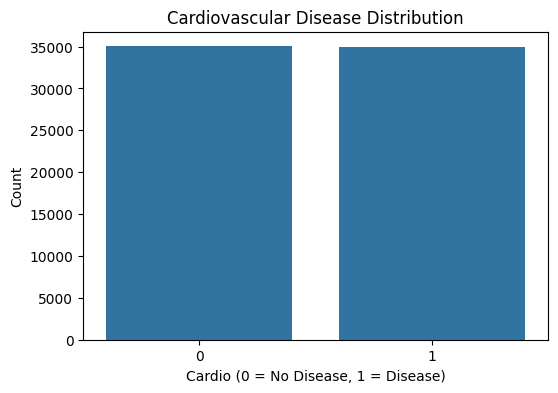

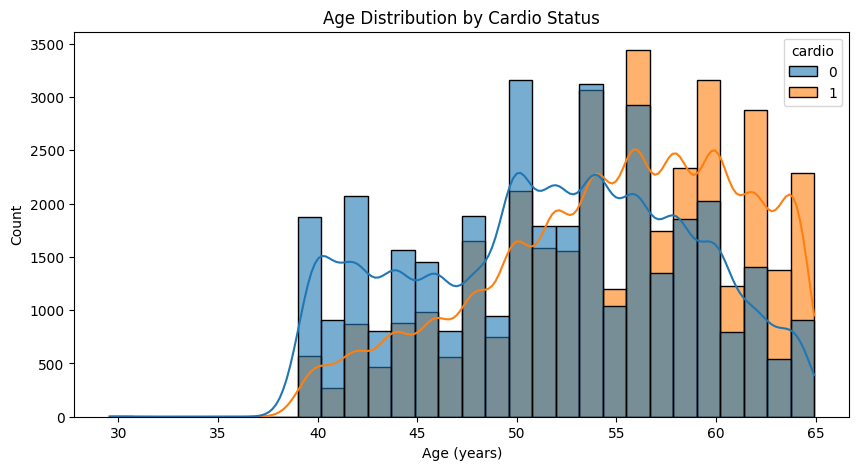

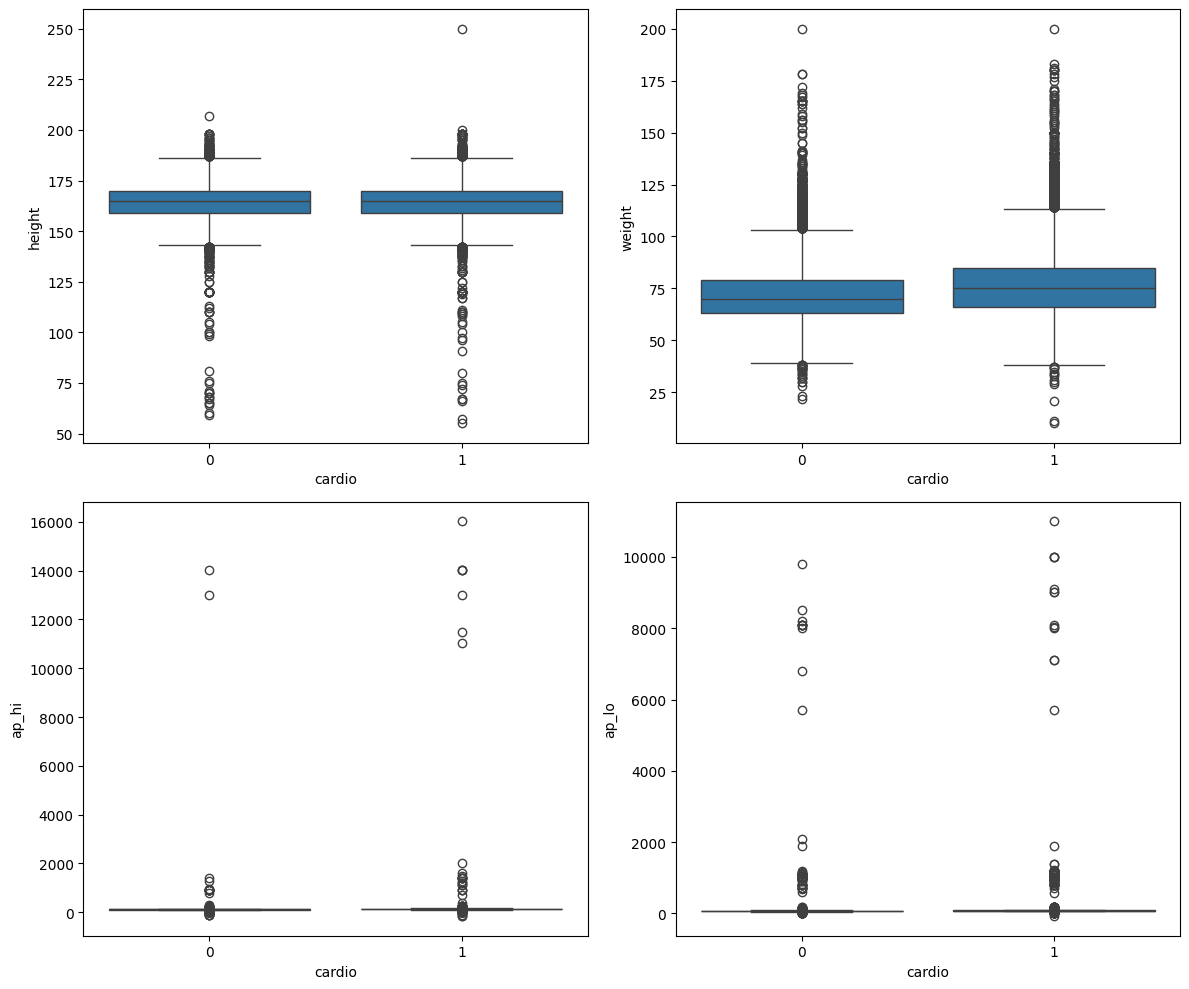

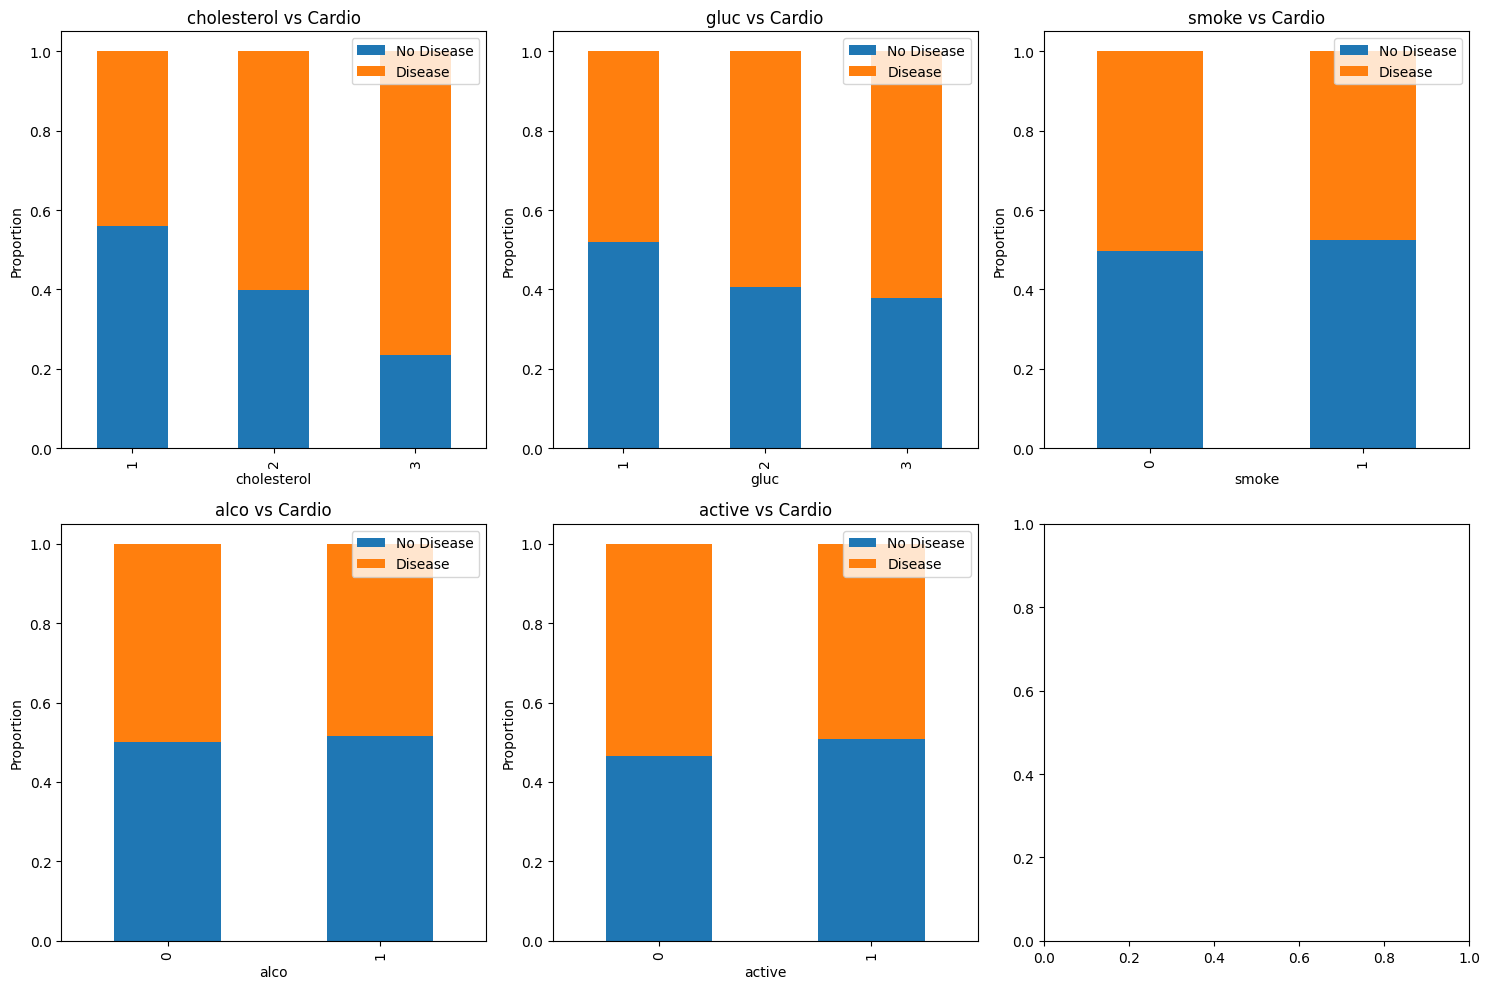

In [4]:
# ==================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ==================================================

# Check target distribution
print("=== Target Distribution ===")
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True) * 100)

# Plot target
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardio (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

# Convert age from days to years for easier interpretation
df['age_years'] = df['age'] / 365.25

# Plot age distribution by target
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age_years', hue='cardio', bins=30, kde=True, alpha=0.6)
plt.title('Age Distribution by Cardio Status')
plt.xlabel('Age (years)')
plt.show()

# Boxplots for key numerical features vs target
fig, axes = plt.subplots(2, 2, figsize=(12,10))
sns.boxplot(x='cardio', y='height', data=df, ax=axes[0,0])
sns.boxplot(x='cardio', y='weight', data=df, ax=axes[0,1])
sns.boxplot(x='cardio', y='ap_hi', data=df, ax=axes[1,0])
sns.boxplot(x='cardio', y='ap_lo', data=df, ax=axes[1,1])
plt.tight_layout()
plt.show()

# Analyze categorical features (cholesterol, gluc, smoke, alco, active)
categorical_cols = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['cardio'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col} vs Cardio')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['No Disease', 'Disease'])
plt.tight_layout()
plt.show()